In [1]:
import PeterChurchillFunctions as Function
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import erf
import statsmodels.api as sm
from scipy.odr import ODR, Model, RealData
from matplotlib.colors import LogNorm
from sklearn.cluster import KMeans


In [2]:
def CCN_CDNC_Dataset(CCN_ds, CDNC_da):
    """
    Compute OLS slope/intercept between CCN(radius, lev, time)
    and CDNC(lev, time) across 'time'.
    """
    CCN_aligned, CDNC_aligned = xr.align(CCN_ds, CDNC_da)

   
    
    ds_out = xr.Dataset(
        data_vars={
            'CCN': CCN_aligned,       # dims: (radius, lev, time)
            'CDNC': CDNC_aligned      # dims: (lev, time)
        },
        coords={
            'radius': CCN_aligned.radius,
            'lev': CCN_aligned.lev,
            'time': CCN_aligned.time
        }
    )

    return ds_out


In [3]:
NorPath = "/share/sabl0586/all_stations_NorESM_OsloAero_prcp2szdst_f19_f19_noresmv211_corr_ilevall_levs_4Peter.nc"
ds = xr.open_dataset(NorPath, chunks={})
stations = ds["station"].values
radii = np.logspace(0, 2.7, 61) #1 to 500 nm RADIUS
VarList = ['FREQL', 'Z3', 'WSUB']
x = xr.DataArray(np.logspace(-0.5,6, num=200), dims =['D'], coords= {'D':np.logspace(-0.5,6, num=200)})

In [4]:
height = ds['Z3'].mean('time')
Updraft = ds['WSUB']

In [5]:
Updraft

<xarray.DataArray 'WSUB' (station: 15, time: 8761, lev: 32)> Size: 17MB
dask.array<open_dataset-WSUB, shape=(15, 8761, 32), dtype=float32, chunksize=(15, 8761, 32), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 70kB 2012-01-02 ... 2015-01-01
  * station  (station) <U8 480B 'ZEP' 'SMR-II' 'ATTO' ... 'Izana' 'Maldives'
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
Attributes: (12/15)
    mdims:            1
    units:            m/s
    long_name:        Diagnostic sub-grid vertical velocity
    pressure_coords:  False
    raw_data_path:    /proj/bolinc/users/x_sarbl/noresm_archive
    model:            NorESM
    ...               ...
    case_name_nice:   OsloAero_prcp2szdst_f19_f19_noresmv211_corr
    isSectional:      False
    from_time:        2012-01-01
    to_time:          2012-02-01
    startyear:        2012
    endyear:          2012

In [6]:
all_stationsCCN = []
all_stationsHeight = []
#CCN_all = xr.open_dataset('/share/pech2273/NorESM_CCN_CDNC.nc')
Downloaded = False
for station in stations:
    if Downloaded is False:
        
        Nor_ds = Function.NorESMExtract_Dask(NorPath, station, VarList, x, PNSD=False)
        CCN_ds = Function.NorERF(Nor_ds, radii)
        
        ## Mask when cloud coverage is above 80%
        Levels_CCN_ds = CCN_CDNC_Dataset(CCN_ds, Nor_ds['CDNC'].where(Nor_ds['FREQL']>0.8))
        all_stationsCCN.append(Levels_CCN_ds.assign_coords(station=station))


# Concatenate across stations
if Downloaded is False:
    CCN_all = xr.concat(all_stationsCCN, dim='station')



#Susceptibility_all = Susceptibility_all.compute()
CCN_all = CCN_all.compute()

/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


In [190]:
def build_susceptibility_dataset_by_station(
    ccn_all_ds,
    radii,
    updraft_ds,
    n_bins=100,
    min_bin_points=2,
    ccn_var="CCN",
    cdnc_var="CDNC",
    output_name=None,
    Binning = 'Equal Number'
):
    import numpy as np
    import xarray as xr
    from scipy import stats

    stations = ccn_all_ds.station.values

    # --- Define updraft quartiles ---
    wsub = updraft_ds
#    q0, q75, q90, q100 = np.nanquantile(wsub, [0, 0.75, 0.90, 1.0])
#    quartile_bins   = [q0, q75, q90, q100]
    quartile_labels = ['Q0-Q75', 'Q75-Q90', 'Q90-Q100', 'Total']
#    ranges          = list(zip(quartile_bins[:-1], quartile_bins[1:])) + [(q0, q100)]

    ds_out = xr.Dataset(
        data_vars={
            "slope":     (["station", "radius", "updraft_q"], np.full((len(stations), len(radii), len(quartile_labels)), np.nan)),
            "r_value":   (["station", "radius", "updraft_q"], np.full((len(stations), len(radii), len(quartile_labels)), np.nan)),
            "std_err":   (["station", "radius", "updraft_q"], np.full((len(stations), len(radii), len(quartile_labels)), np.nan)),
            "intercept": (["station", "radius", "updraft_q"], np.full((len(stations), len(radii), len(quartile_labels)), np.nan)),
        },
        coords={"station": stations, "radius": radii, "updraft_q": quartile_labels}
    )

    for s, station in enumerate(stations):
    
        wsub_slice = wsub.sel(station=station)
    
        # --- Define updraft quartiles per station ---
        q0, q75, q90, q100 = np.nanquantile(wsub_slice, [0, 0.75, 0.90, 1.0])
        quartile_bins   = [q0, q75, q90, q100]
        ranges = list(zip(quartile_bins[:-1], quartile_bins[1:])) + [(q0, q100)]
        for r_idx, r_val in enumerate(radii):
    
            CCN_slice  = ccn_all_ds[ccn_var].sel(station=station).isel(radius=r_idx)
            CDNC_slice = ccn_all_ds[cdnc_var].sel(station=station)
            wsub_slice = wsub.sel(station=station)
    
            for q_idx, (q_label, (lo, hi)) in enumerate(zip(quartile_labels, ranges)):
    
                # --- Mask by updraft quartile ---
                q_mask = (wsub_slice >= lo) & (wsub_slice <= hi)
                CCN_q  = CCN_slice.where(q_mask).values
                CDNC_q = CDNC_slice.where(q_mask).values
    
                # --- Drop NaNs ---
                valid  = np.isfinite(CCN_q) & np.isfinite(CDNC_q)
                CCN_v  = CCN_q[valid]
                CDNC_v = CDNC_q[valid]
    
                if CCN_v.size < 2:
                    continue
    
                lx = np.log10(CCN_v)
                ly = np.log10(CDNC_v)
    
                # --- Choose binning ---
                if Binning == 'Equal Space':
                    try:
                        bins = np.linspace(lx.min(), lx.max(), n_bins + 1)
                    except ValueError:
                        continue
    
                elif Binning == 'Equal Number':
                    # Equal-frequency bins
                    bins = np.quantile(lx, np.linspace(0, 1, n_bins + 1))
    
                    # Remove duplicate edges
                    bins = np.unique(bins)
    
                    # If too few bins remain, skip
                    if len(bins) < 3:
                        continue
    
                else:
                    raise ValueError("Binning must be 'Equal Space' or 'Equal Number'")
    
                # --- Compute median per bin ---
                lx_mean = []
                ly_mean = []
    
                for b in range(len(bins) - 1):
                    if b == len(bins) - 2:
                        mask_bin = (lx >= bins[b]) & (lx <= bins[b+1])
                    else:
                        mask_bin = (lx >= bins[b]) & (lx < bins[b+1])
    
                    if np.sum(mask_bin) >= min_bin_points:
                        lx_mean.append(np.median(lx[mask_bin]))
                        ly_mean.append(np.median(ly[mask_bin]))
    
                lx_mean = np.array(lx_mean)
                ly_mean = np.array(ly_mean)
    
                # --- Final validity check ---
                finite = np.isfinite(lx_mean) & np.isfinite(ly_mean)
                if finite.sum() < min_bin_points:
                    continue
    
                # --- Linear regression ---
                slope, intercept, r_value, p_value, std_err = stats.linregress(
                    lx_mean[finite], ly_mean[finite]
                )
    
                # --- Store results ---
                ds_out["slope"].values[s, r_idx, q_idx]     = slope
                ds_out["r_value"].values[s, r_idx, q_idx]   = r_value
                ds_out["std_err"].values[s, r_idx, q_idx]   = std_err
                ds_out["intercept"].values[s, r_idx, q_idx] = intercept
        if output_name is not None:
            ds_out.attrs["name"] = output_name

    return ds_out



In [191]:
Equal_Space_reg_ds = build_susceptibility_dataset_by_station(CCN_all, radii, Updraft, Binning = 'Equal Space')

In [192]:
Equal_Number_reg_ds = build_susceptibility_dataset_by_station(CCN_all, radii, Updraft, Binning = 'Equal Number')

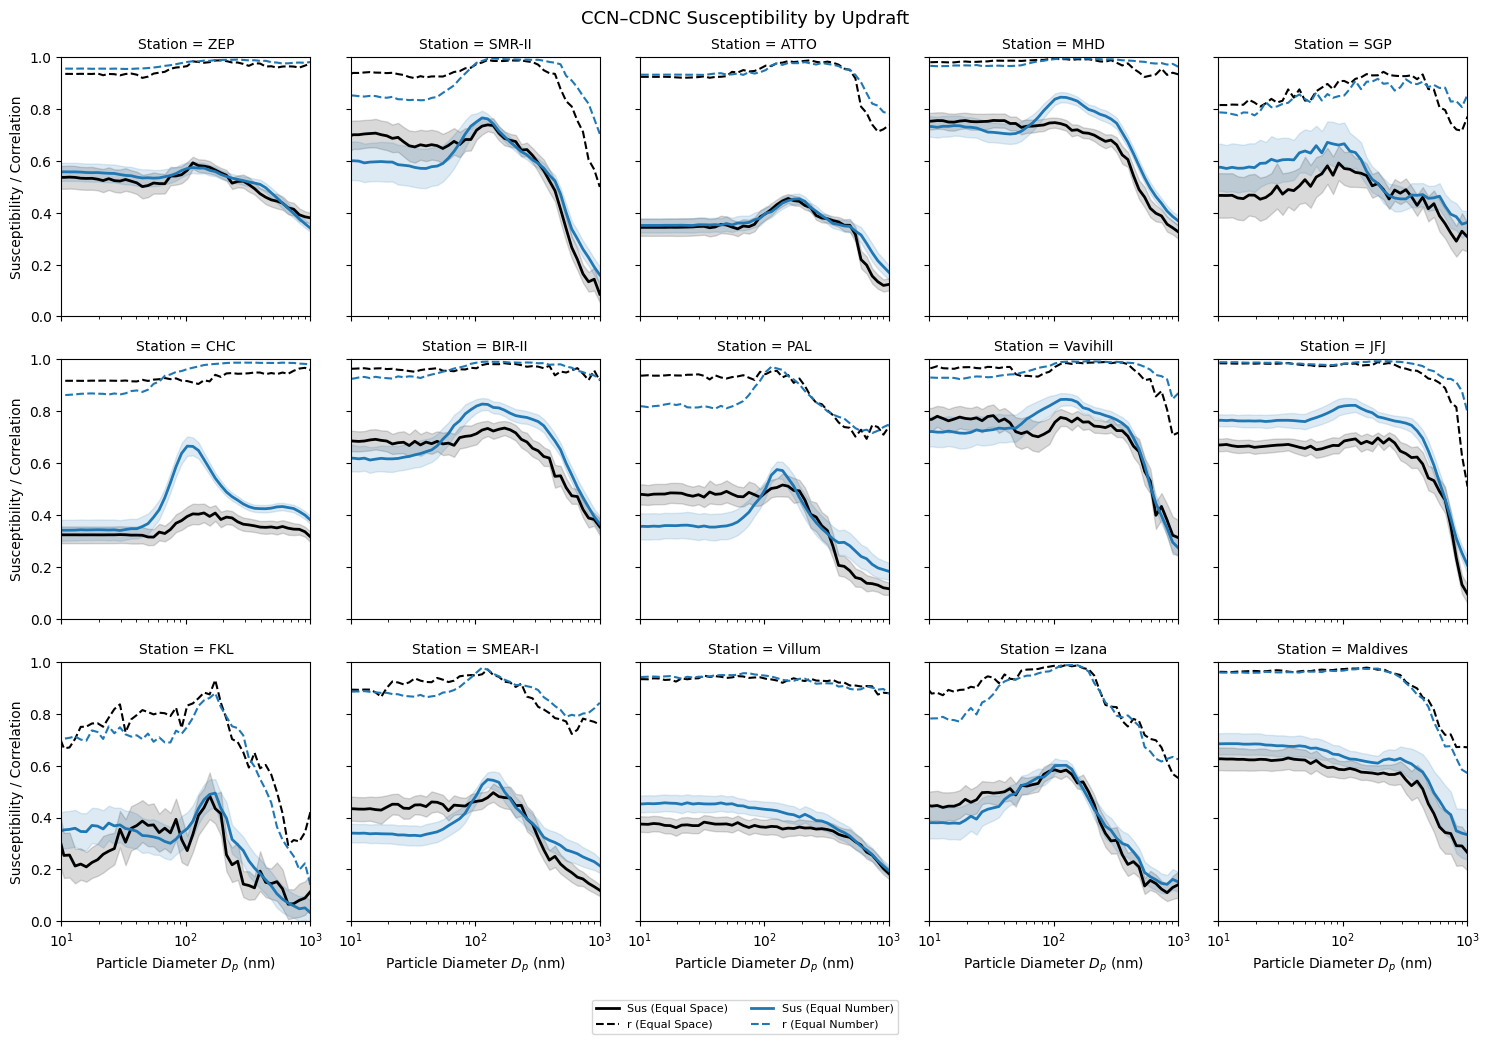

In [193]:
colors = {
    'Equal Space': 'black',
    'Equal Number': 'tab:blue'
}
stations = reg_ds.station.values


fig, axes = plt.subplots(3, 5, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, station in zip(axes, stations):
    for q_label in ['Total']:  # since you're only using Total

        ds  = Equal_Space_reg_ds.sel(updraft_q=q_label, station=station)
        ds2 = Equal_Number_reg_ds.sel(updraft_q=q_label, station=station)

        # --- Equal Space ---
        ax.plot(ds['radius']*2, ds['slope'],
                color=colors['Equal Space'], linewidth=2,
                label='Sus (Equal Space)')
        
        ax.fill_between(ds['radius']*2,
                        ds['slope'] - 1.98*ds['std_err'],
                        ds['slope'] + 1.98*ds['std_err'],
                        color=colors['Equal Space'], alpha=0.15)

        ax.plot(ds['radius']*2, ds['r_value'],
                '--', color=colors['Equal Space'], linewidth=1.5,
                label='r (Equal Space)')

        # --- Equal Number ---
        ax.plot(ds2['radius']*2, ds2['slope'],
                color=colors['Equal Number'], linewidth=2,
                label='Sus (Equal Number)')
        
        ax.fill_between(ds2['radius']*2,
                        ds2['slope'] - 1.98*ds2['std_err'],
                        ds2['slope'] + 1.98*ds2['std_err'],
                        color=colors['Equal Number'], alpha=0.15)

        ax.plot(ds2['radius']*2, ds2['r_value'],
                '--', color=colors['Equal Number'], linewidth=1.5,
                label='r (Equal Number)')

    ax.set_title(F'Station = {station}', fontsize=10)
    ax.set_ylim([0, 1])
    ax.set_xlim([10, 1000])
    ax.set_xscale('log')

# Shared axis labels
for ax in axes[10:]:  # bottom row
    ax.set_xlabel('Particle Diameter $D_p$ (nm)')
for ax in axes[::5]:  # left column
    ax.set_ylabel('Susceptibility / Correlation')

# Single shared legend outside the subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', fontsize=8,
           ncols=len(colors), bbox_to_anchor=(0.5, -0.05))

fig.suptitle('CCN–CDNC Susceptibility by Updraft', fontsize=13)
plt.tight_layout()
plt.show()

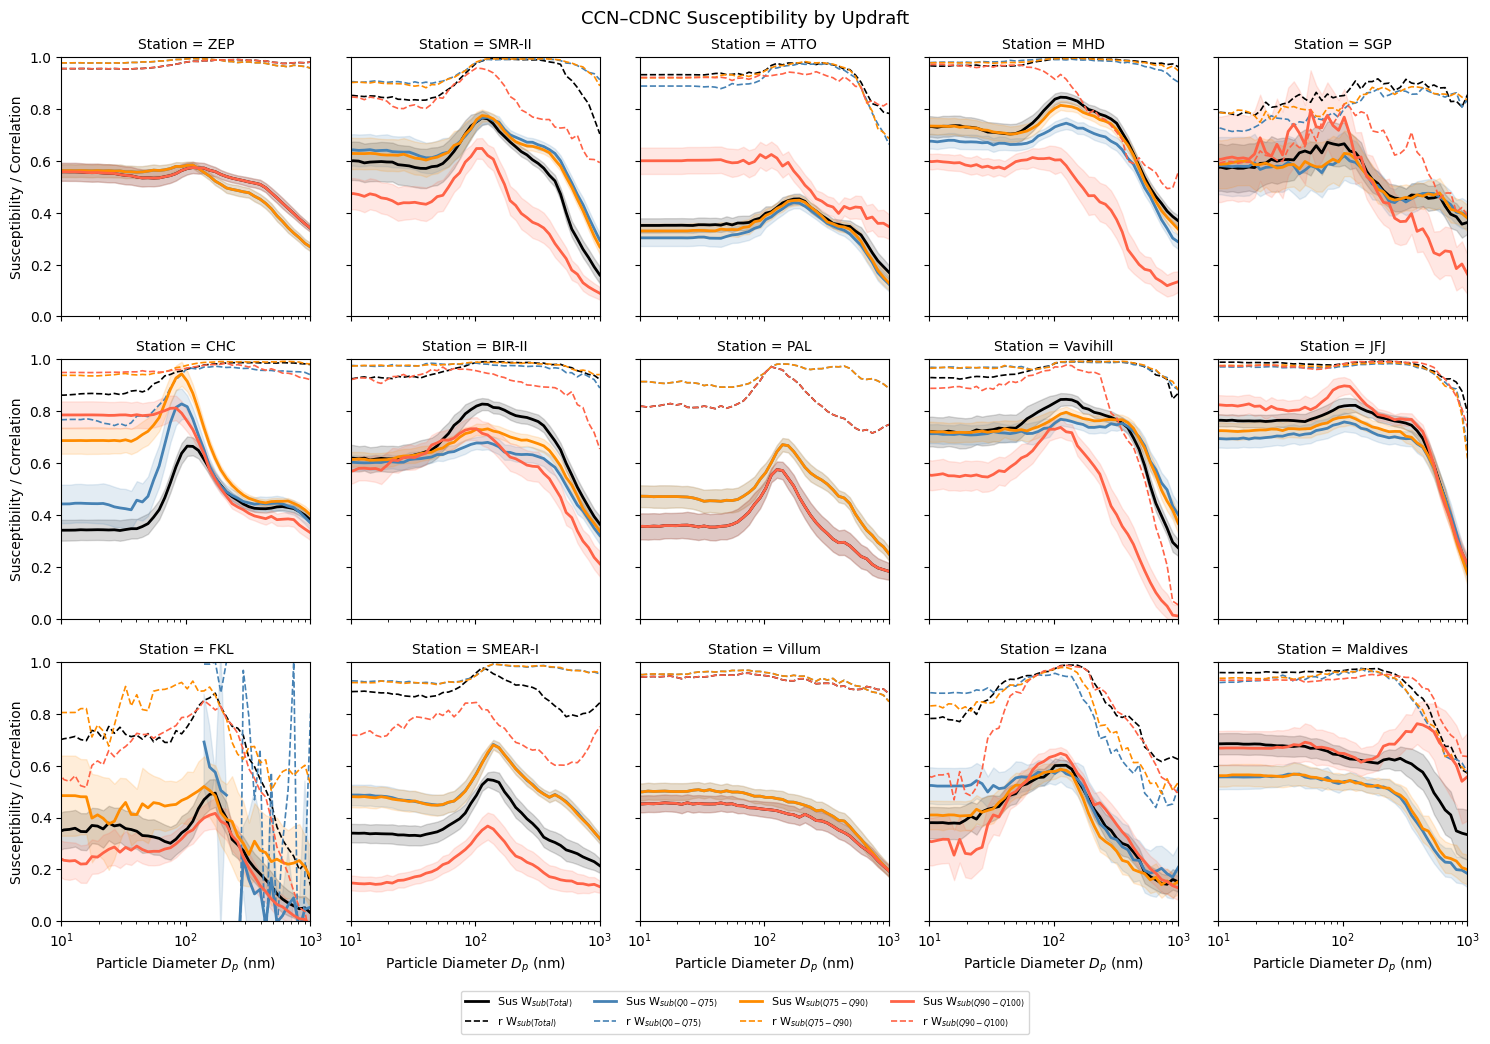

In [194]:
colors = {
    'Total':    'black',
    'Q0-Q75':   'steelblue',
    'Q75-Q90':  'darkorange',
    'Q90-Q100': 'tomato',
}
stations = Equal_Number_reg_ds.station.values


fig, axes = plt.subplots(3, 5, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, station in zip(axes, stations):
    for q_label, color in colors.items():
        ds = Equal_Number_reg_ds.sel(updraft_q=q_label, station = station)

        ax.plot(ds['radius']*2, ds['slope'],
                color=color, linewidth=2,
                label=f'Sus W$_{{sub ({q_label})}}$')
        ax.fill_between(ds['radius']*2,
                        ds['slope'] - 1.98*ds['std_err'],
                        ds['slope'] + 1.98*ds['std_err'],
                        color=color, alpha=0.15)
        ax.plot(ds['radius']*2, ds['r_value'],
                '--', color=color, linewidth=1.2,
                label=f'r W$_{{sub ({q_label})}}$')

    ax.set_title(F'Station = {station}', fontsize=10)
    ax.set_ylim([0, 1])
    ax.set_xlim([10, 1000])
    ax.set_xscale('log')

# Shared axis labels
for ax in axes[10:]:  # bottom row
    ax.set_xlabel('Particle Diameter $D_p$ (nm)')
for ax in axes[::5]:  # left column
    ax.set_ylabel('Susceptibility / Correlation')

# Single shared legend outside the subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', fontsize=8,
           ncols=len(colors), bbox_to_anchor=(0.5, -0.05))

fig.suptitle('CCN–CDNC Susceptibility by Updraft', fontsize=13)
plt.tight_layout()
plt.show()

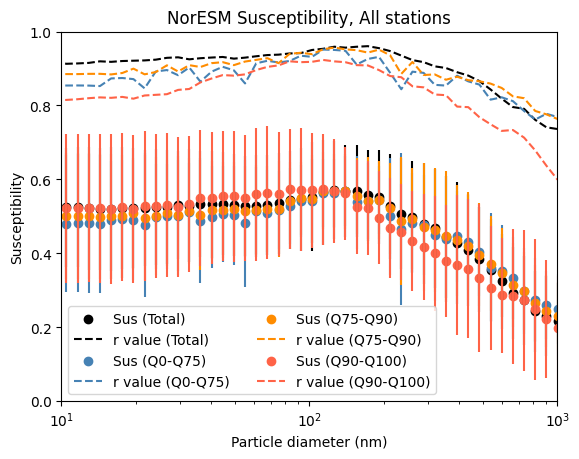

In [187]:
for q_label, color in colors.items(): 
    plt.scatter(reg_ds['radius']*2,reg_ds['slope'].sel(updraft_q = q_label).mean('station'), label = f'Sus ({q_label})', c = color)
    plt.errorbar(reg_ds['radius']*2,reg_ds['slope'].sel(updraft_q = q_label).mean('station'), reg_ds['slope'].sel(updraft_q = q_label).std('station'),    fmt='none', ecolor = color )
    plt.plot(reg_ds['radius']*2,reg_ds['r_value'].sel(updraft_q = q_label).mean('station'), label = f'r value ({q_label})', c =color, ls = '--')
    
    plt.xscale('log')
    plt.ylim([0,1])
    plt.xlim([10,1000])
    plt.xlabel('Particle diameter (nm)')
    plt.ylabel('Susceptibility')
    plt.title('NorESM Susceptibility, All stations')
    plt.legend(ncol = 2)


In [177]:
CCN_all.CDNC.sel(station = 'FKL').dropna('time', how = 'all')

<xarray.DataArray 'CDNC' (time: 460, lev: 32)> Size: 59kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(460, 32), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 4kB 2012-01-03T18:00:00 ... 2014-12-29T09:...
    station  <U8 32B 'FKL'
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6

In [158]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
def updraft_susceptibility_graph(radius, station):
    r = radius
    wsub = Updraft.sel(station = station)
    log_x = np.log10(CCN_all['CCN'].isel(radius=r).sel(station = station).where(CCN_all['CDNC'].sel(station = station)>0))
    log_y = np.log10(CCN_all['CDNC'].sel(station = station))
    xmin = log_x.min().values
    xmax = log_x.max().values
    ymin = log_y.min().values
    ymax = log_y.max().values
    Graphmin = np.min([xmin, ymin])
    Graphmax = np.max([xmax, ymax])
    print(Graphmin, Graphmax)
    plotline = np.linspace(Graphmin, Graphmax, 20)
    
    
    # --- Updraft quartile boundaries ---
    q0, q75, q90, q100 = np.nanquantile(wsub, [0, 0.75, .9, 1.0])
    
    quartile_bins = [q0, q75, q90, q100]
    quartile_labels = ['Q0-Q75', 'Q75-Q90', 'Q90-Q100']
    colors = ['steelblue', 'seagreen', 'darkorange']
    
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    axes = axes.flatten()
    
    # --- GLOBAL COLOR SCALE ---
    vmin = float(np.nanquantile(wsub, 0.05))
    vmax = float(np.nanquantile(wsub, 0.95))
    
    hb_ref = None  # for shared colorbar
    
    # ---------- PANEL 0: TOTAL ----------
    ax = axes[0]
    
    valid = np.isfinite(log_x.values) & np.isfinite(log_y.values) & np.isfinite(wsub.values)
    
    lx = log_x.values[valid]
    ly = log_y.values[valid]
    w  = wsub.values[valid]
    
    n_points = len(lx)
    
    hb = ax.hexbin(
        lx, ly,
        C=w,
        reduce_C_function=np.mean,
        cmap='viridis',
        gridsize=[30, 30],
        vmin=vmin, vmax=vmax,
        mincnt=1,
        edgecolors='none',
        extent=[Graphmin, Graphmax, Graphmin, Graphmax],
    )
    
    if hb_ref is None:
        hb_ref = hb
    
    # Total regression
    slope = reg_ds.slope.isel(radius=r).sel(updraft_q='Total', station = station).values
    intercept = reg_ds.intercept.isel(radius=r).sel(updraft_q='Total', station = station).values
    
    ax.plot(plotline, plotline * slope + intercept,
            color='black', linewidth=2, ls = '--',
            label=f'slope={slope:.2f}')
    
    ax.plot([Graphmin, Graphmax], [Graphmin, Graphmax], 'r--')
    ax.set_title(f'Total (N={n_points})')
    ax.legend()
    
    
    # ---------- QUARTILES ----------
    for i, (lo, hi, label, color) in enumerate(zip(
            quartile_bins[:-1], quartile_bins[1:], quartile_labels, colors)):
    
        ax = axes[i + 1]
    
        mask = ((wsub >= lo) & (wsub <= hi)).values
    
        lx = log_x.values[mask]
        ly = log_y.values[mask]
        w  = wsub.values[mask]
    
        valid = np.isfinite(lx) & np.isfinite(ly) & np.isfinite(w)
        lx, ly, w = lx[valid], ly[valid], w[valid]
    
        n_points = len(lx)
    
        if n_points < 2:
            continue
    
        # --- HEXBIN ---
        hb = ax.hexbin(
            lx, ly,
            C=w,
            reduce_C_function=np.mean,
            cmap='viridis',
            gridsize=[30, 30],
            vmin=vmin, vmax=vmax,
            mincnt=1,
            edgecolors='none',
            extent=[Graphmin, Graphmax, Graphmin, Graphmax],
        )
    
        if hb_ref is None:
            hb_ref = hb
    
        xmin = np.nanmin(lx)
        xmax = np.nanmax(lx)
    
        if not np.isfinite(xmin) or not np.isfinite(xmax) or xmin == xmax:
            continue
    
        Log_bins = np.linspace(xmin, xmax, 101)
        bin_idx = np.digitize(lx, Log_bins)
    
        lx_mean = np.array([
            lx[bin_idx == b].mean() if np.any(bin_idx == b) else np.nan
            for b in range(1, len(Log_bins))
        ])
    
        ly_mean = np.array([
            ly[bin_idx == b].mean() if np.any(bin_idx == b) else np.nan
            for b in range(1, len(Log_bins))
        ])
    
        valid_bins = np.isfinite(lx_mean) & np.isfinite(ly_mean)
        lx_mean, ly_mean = lx_mean[valid_bins], ly_mean[valid_bins]
    
        ax.scatter(lx_mean, ly_mean, color=color, s=10, label='Bin means')
    
    
        slope_ds = reg_ds.slope.isel(radius=r).sel(updraft_q=label, station = station).values
        intercept_ds = reg_ds.intercept.isel(radius=r).sel(updraft_q=label, station = station).values
    
        ax.plot(plotline, plotline * slope_ds + intercept_ds,
                color=color, linestyle='--',
                label=f'Susceptibility = {slope_ds:.2f}')
    
        ax.plot([Graphmin, Graphmax], [Graphmin, Graphmax], 'r--')
    
        ax.set_title(f'W$_{{sub ({label})}}$ (N={n_points})')
        ax.legend(fontsize=7)
    
    
    # ---------- FORMAT ----------
    for ax in axes:
        ax.set_xlim([Graphmin, Graphmax])
        ax.set_ylim([Graphmin, Graphmax])
        ax.set_xlabel('log$_{10}$(CCN)')
        ax.set_ylabel('log$_{10}$(CDNC)')
    
    
    # ---------- OUTSIDE COLORBAR ----------
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(hb_ref, cax=cbar_ax, label='Mean W$_{sub}$ (m/s)')
    
    plt.suptitle(f'{station} Susceptibility by Updraft (Dp = {reg_ds.radius[r]*2:.2f} nm)')
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    
    plt.show()

0.9043256640434265 3.933773459200885


/tmp/ipykernel_2466228/3720174098.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


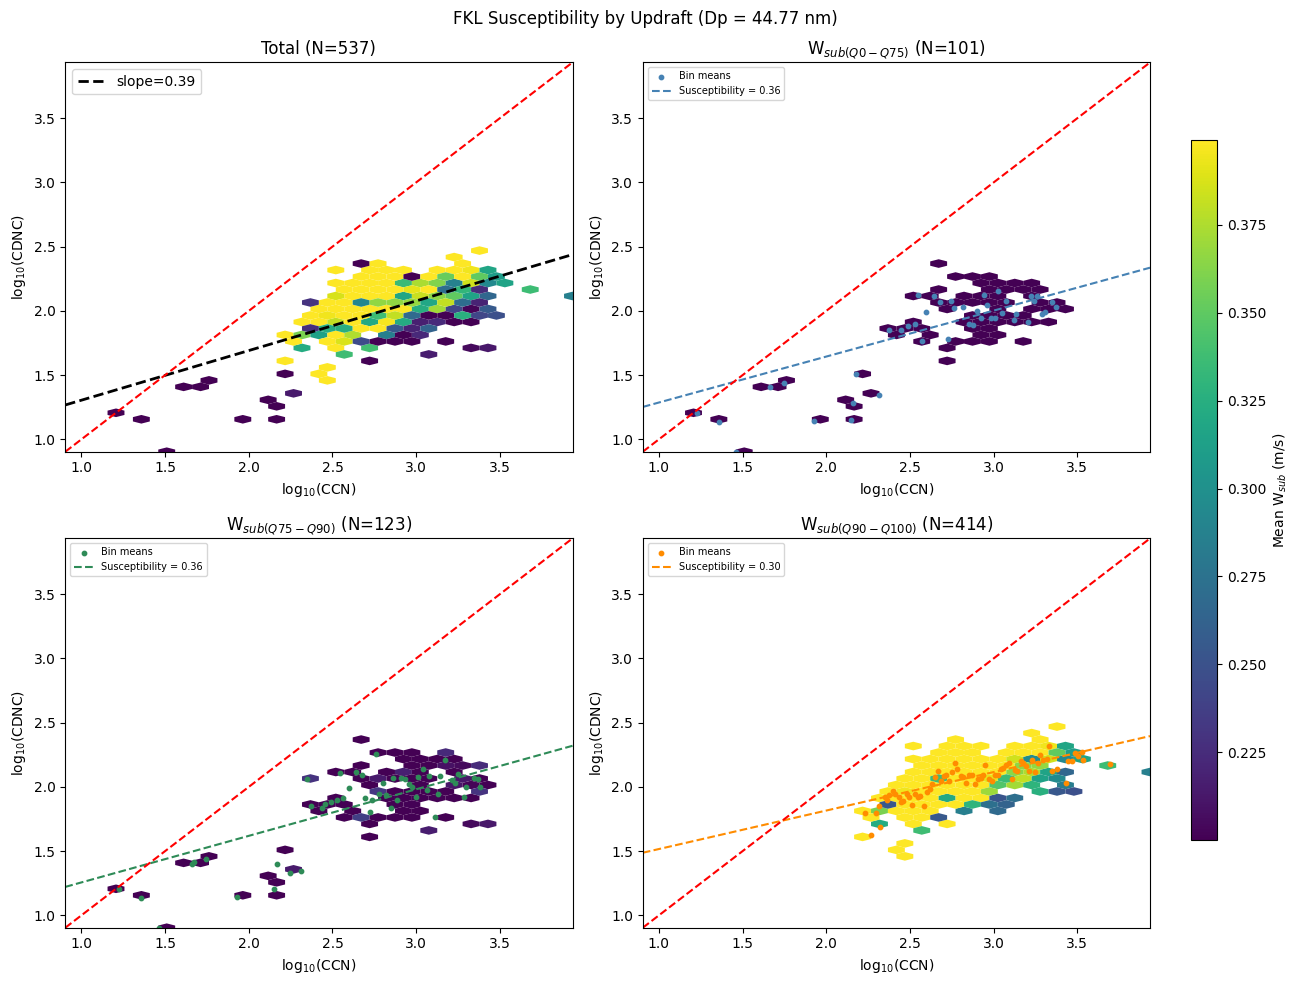

In [173]:
updraft_susceptibility_graph(radius = 30, station = 'FKL')

In [114]:
Sus_enhancement = ((reg_ds.slope.sel(updraft_q = 'Q90-Q100')-reg_ds.slope.sel(updraft_q = 'Total'))/reg_ds.slope.sel(updraft_q = 'Total')*100).mean('radius')

In [133]:
Sus_enhancement.isel(station = Sus_enhancement.argmax())

<xarray.DataArray 'slope' ()> Size: 8B
array(66.83982308)
Coordinates:
    station    <U8 32B 'CHC'
    updraft_q  <U8 32B 'Total'

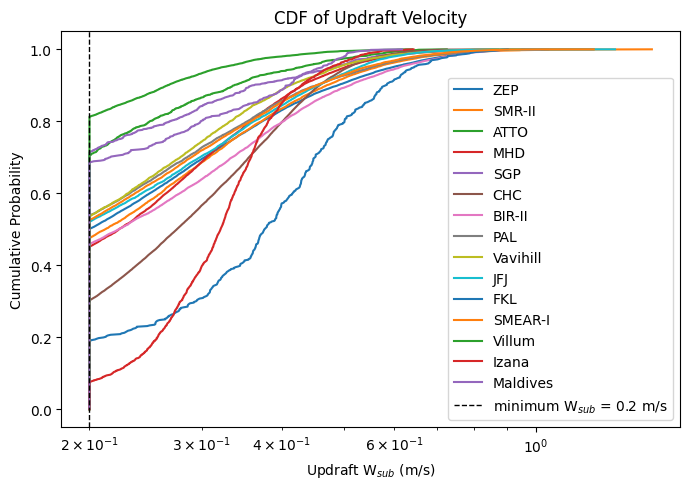

In [108]:
fig, ax = plt.subplots(figsize=(7, 5))

for station in Updraft.station:
    data = Updraft.sel(station = station).where(CCN_all.CDNC.sel(station = station)>0, drop = True).values.flatten()
    vals = data[np.isfinite(data)]
    vals_sorted = np.sort(vals)
    cdf = np.arange(1, len(vals_sorted) + 1) / len(vals_sorted)
    ax.plot(vals_sorted, cdf, label=station.values)

ax.axvline(0.2, color='k', linestyle='--', linewidth=1, label='minimum W$_{sub}$ = 0.2 m/s')
ax.set_xscale('log')
ax.set_xlabel('Updraft W$_{sub}$ (m/s)')
ax.set_ylabel('Cumulative Probability')
ax.set_title('CDF of Updraft Velocity')
ax.legend()
plt.tight_layout()
plt.show()

<>:44: SyntaxWarning: invalid escape sequence '\D'
<>:44: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2466228/3827516232.py:44: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('$\Delta$% Susceptiblity')


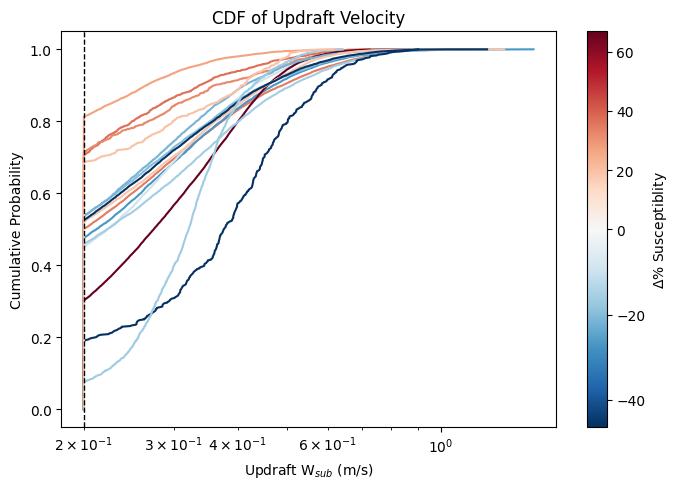

In [138]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(7, 5))

# --- get Sus_enhancement values ---
sus_vals = Sus_enhancement.values

# centered normalization
norm = mcolors.TwoSlopeNorm(
    vmin=np.nanmin(sus_vals),
    vcenter=0,
    vmax=np.nanmax(sus_vals)
)

cmap = cm.RdBu_r   # nice diverging colormap (blue ↔ red)

# --- plotting ---
for i, station in enumerate(Updraft.station):
    data = Updraft.sel(station=station).where(
        CCN_all.CDNC.sel(station=station) > 0,
        drop=True
    )

    vals = data.values.flatten()
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        continue

    vals_sorted = np.sort(vals)
    cdf = np.arange(1, len(vals_sorted) + 1) / len(vals_sorted)

    sus_val = Sus_enhancement.sel(station=station).values.item()
    color = cmap(norm(sus_val))

    ax.plot(vals_sorted, cdf, color=color, label=str(station.values))

# colorbar
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('$\Delta$% Susceptiblity')

ax.axvline(0.2, color='k', linestyle='--', linewidth=1)

ax.set_xlabel('Updraft W$_{sub}$ (m/s)')
ax.set_ylabel('Cumulative Probability')
ax.set_title('CDF of Updraft Velocity')
ax.set_xscale('log')
plt.tight_layout()
plt.show()


In [126]:
Updraft90th = Updraft.where(CCN_all.CDNC > 0, drop=True) \
       .quantile(0.9, dim=[d for d in Updraft.dims if d != "station"])

Text(0, 0.5, '% change in Susceptibility at 90th Percentile updraft')

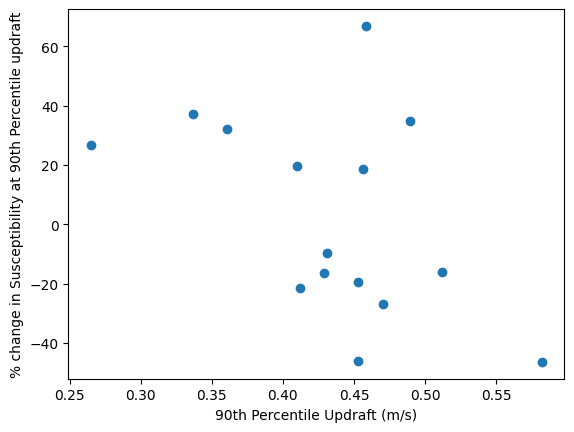

In [141]:
plt.scatter(Updraft90th, Sus_enhancement)
plt.xlabel('90th Percentile Updraft (m/s)')
plt.ylabel('% change in Susceptibility at 90th Percentile updraft')

In [142]:
CHC_composition = Function.NorComposition(NorPath, 'CHC')

In [143]:
CHC_composition

<xarray.Dataset> Size: 12MB
Dimensions:       (time: 8761, lev: 32)
Coordinates:
  * time          (time) datetime64[ns] 70kB 2012-01-02 ... 2015-01-01
    station       <U8 32B 'CHC'
  * lev           (lev) float64 256B 3.643 7.595 14.36 ... 957.5 976.3 992.6
Data variables:
    OA_Mass       (time, lev) float32 1MB 1.331e-11 7.247e-11 ... 4.366e-09
    SO4_Mass      (time, lev) float32 1MB 4.441e-12 2.179e-11 ... 4.147e-10
    Seasalt_Mass  (time, lev) float32 1MB 3.225e-24 1.177e-20 ... 3.053e-11
    Dust_Mass     (time, lev) float32 1MB 6.604e-23 1.452e-19 ... 9.156e-11
    BC_Mass       (time, lev) float32 1MB 2.052e-12 7.698e-12 ... 1.793e-11
    Total_Mass    (time, lev) float32 1MB 1.98e-11 1.02e-10 ... 4.92e-09
    OA_Frac       (time, lev) float32 1MB 0.6721 0.7108 0.726 ... 0.8919 0.8873
    SO4_Frac      (time, lev) float32 1MB 0.2243 0.2137 ... 0.08168 0.08428
    Seasalt_Frac  (time, lev) float32 1MB 1.628e-13 1.155e-10 ... 0.006205
    Dust_Frac     (time, lev) float32 1MB 3.335e-12 1.424e-09 ... 0.01861
    BC_Frac       (time, lev) float32 1MB 0.1036 0.07551 ... 0.003536 0.003643

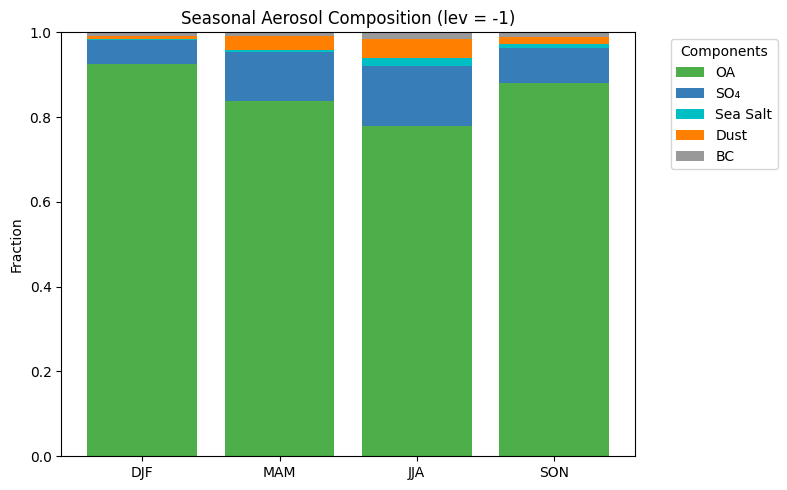

In [151]:

frac_vars = ['OA_Frac', 'SO4_Frac', 'Seasalt_Frac', 'Dust_Frac', 'BC_Frac']
labels = ['OA', 'SO₄', 'Sea Salt', 'Dust', 'BC']
# --- select surface level ---
ds = CHC_composition.isel(lev=-1)

# --- if you have stations, average them (optional) ---
if "station" in ds.dims:
    ds = ds.mean(dim="station")

# --- seasonal mean ---
seasonal = ds[frac_vars].groupby("time.season").mean()

# enforce consistent season order
season_order = ["DJF", "MAM", "JJA", "SON"]
seasonal = seasonal.sel(season=season_order)

# --- stack data ---
data = np.array([seasonal[var].values for var in frac_vars])

# normalize (safety)
data = data / data.sum(axis=0)

# --- plotting ---
fig, ax = plt.subplots(figsize=(8, 5))

bottom = np.zeros(len(season_order))

colors = ['#4daf4a', '#377eb8', '#00bfc4', '#ff7f00', '#999999']

for i, var in enumerate(frac_vars):
    ax.bar(season_order, data[i], bottom=bottom,
           label=labels[i], color=colors[i])
    bottom += data[i]

# --- styling ---
ax.set_ylabel("Fraction")
ax.set_title('Seasonal Aerosol Composition at surface level')
ax.set_ylim(0, 1)

ax.legend(title="Components", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()
